# 04 - Model Selection: 5 Models × 4 Techniques = 20 Experiments!
**CA2 Sprint 2 - Machine Learning Pipeline**

## 🚀 UPDATED VERSION:
**This notebook combines everything we've learned:**

### Features:
- ✅ **10 selected features** (from Phase 1B - matching notebook 03)
- ✅ 63% reduction in complexity (27 → 10)
- ✅ Same performance, better UX

### The 10 Selected Features:
1. trip_duration_sec
2. speed_mean
3. turn_sharpness_index
4. pct_time_cruising
5. gyro_accel_instability
6. speed_max
7. pct_time_high_accel
8. jerk_linear_mean
9. accel_risk_score
10. longest_smooth_segment_sec

### Imbalance Techniques (4 Experiments per Model):
1. ✅ **Class Weights (Default 0.5)** - Baseline with penalty
2. ✅ **SMOTE (Default 0.5)** - Baseline with oversampling
3. ✅ **Class Weights + Tuned Threshold** - Enhanced with optimal threshold
4. ✅ **SMOTE + Tuned Threshold** - Enhanced with optimal threshold

### Models (5 algorithms):
1. Logistic Regression (Baseline)
2. Random Forest
3. XGBoost
4. LightGBM
5. Gradient Boosting

### Total Experiments:
**5 models × 4 techniques = 20 MLflow runs!** 🎉

### Key Correction:
- ✅ Tree-based models (RF, XGB, LGBM, GB): **NO scaling**
- ✅ Linear models (LR): **WITH scaling**

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import time
from pathlib import Path

# ML imports
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create directories
os.makedirs('../notebooks/figures', exist_ok=True)

print("✅ Libraries loaded successfully!")
print("\n🚀 UPDATED VERSION:")
print("   - 10 selected features (matching notebook 03)")
print("   - 5 models tested")
print("   - 4 imbalance techniques EACH (CW, SMOTE, CW+Tuned, SMOTE+Tuned)")
print("   - Total: 20 experiments!")
print("\n⚡ Preprocessing:")
print("   - Tree-based models: NO scaling")
print("   - Linear models: WITH scaling")

✅ Libraries loaded successfully!

🚀 UPDATED VERSION:
   - 10 selected features (matching notebook 03)
   - 5 models tested
   - 4 imbalance techniques EACH (CW, SMOTE, CW+Tuned, SMOTE+Tuned)
   - Total: 20 experiments!

⚡ Preprocessing:
   - Tree-based models: NO scaling
   - Linear models: WITH scaling


## 2. Helper Functions for MLflow Logging

In [2]:
def log_confusion_matrix_to_mlflow(y_true, y_pred, run_name):
    """
    Create confusion matrix and log to MLflow as artifact
    """
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Safe', 'Dangerous'],
                yticklabels=['Safe', 'Dangerous'],
                cbar_kws={'label': 'Count'})
    ax.set_title(f'Confusion Matrix - {run_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)
    
    # Save temporarily
    temp_path = f'temp_cm_{run_name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(temp_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    # Log to MLflow
    mlflow.log_artifact(temp_path)
    
    # Clean up
    os.remove(temp_path)
    
    return cm

def log_roc_curve_to_mlflow(y_true, y_proba, run_name):
    """
    Create ROC curve and log to MLflow as artifact
    """
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
            label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve - {run_name}', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(alpha=0.3)
    
    # Save temporarily
    temp_path = f'temp_roc_{run_name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(temp_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    # Log to MLflow
    mlflow.log_artifact(temp_path)
    
    # Clean up
    os.remove(temp_path)

def find_optimal_threshold(y_true, y_proba):
    """Finds threshold that maximizes F1-score (same as notebook 03)"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    # Add epsilon to avoid division by zero
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

print("✅ Helper functions defined!")

✅ Helper functions defined!


## 3. MLflow Configuration

In [3]:
# Set MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("gobest-cab-driver-safety")

print("🔬 MLflow connected!")
print("📊 All 20 runs will be tracked in the same experiment")
print("\n⚠️  Make sure MLflow server is running:")
print("   mlflow ui --host 0.0.0.0 --port 5000")

🔬 MLflow connected!
📊 All 20 runs will be tracked in the same experiment

⚠️  Make sure MLflow server is running:
   mlflow ui --host 0.0.0.0 --port 5000


## 4. Load Data & Apply Feature Selection

In [4]:
print("📂 Loading data and applying feature selection...")
print("="*60)

# Load full dataset
X_train_full = pd.read_csv('../data/processed/X_train.csv')
X_val_full = pd.read_csv('../data/processed/X_val.csv')
X_test_full = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# ==============================================================================
# 🎯 DEFINE THE 10 SELECTED FEATURES (MATCHING NOTEBOOK 03)
# ==============================================================================
selected_features = [
    'trip_duration_sec',
    'speed_mean',
    'turn_sharpness_index',
    'pct_time_cruising',
    'gyro_accel_instability',  # Engineered Feature
    'speed_max',
    'pct_time_high_accel',
    'jerk_linear_mean',
    'accel_risk_score',        # Engineered Feature
    'longest_smooth_segment_sec'
]

# Apply feature selection
X_train = X_train_full[selected_features].copy()
X_val = X_val_full[selected_features].copy()
X_test = X_test_full[selected_features].copy()

print(f"✅ Dataset loaded with {len(selected_features)} selected features")
print(f"   Training:   {X_train.shape}")
print(f"   Validation: {X_val.shape}")
print(f"   Test:       {X_test.shape}")

print(f"\n📋 The 10 Selected Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print(f"\n📊 Class distribution (training):")
for label, count in zip(unique, counts):
    label_name = "Safe" if label == 0 else "Dangerous"
    print(f"   {label_name} ({label}): {count:6,} ({count/len(y_train)*100:.1f}%)")

📂 Loading data and applying feature selection...
✅ Dataset loaded with 10 selected features
   Training:   (11880, 10)
   Validation: (4000, 10)
   Test:       (4000, 10)

📋 The 10 Selected Features:
    1. trip_duration_sec
    2. speed_mean
    3. turn_sharpness_index
    4. pct_time_cruising
    5. gyro_accel_instability
    6. speed_max
    7. pct_time_high_accel
    8. jerk_linear_mean
    9. accel_risk_score
   10. longest_smooth_segment_sec

📊 Class distribution (training):
   Safe (0):  8,988 (75.7%)
   Dangerous (1):  2,892 (24.3%)


## 5. Prepare Data: Scaled (for LR) and Unscaled (for Trees)

In [5]:
print("🔧 Preparing scaled and unscaled versions...")
print("="*60)

# SCALED version (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# UNSCALED version (for tree-based models)
X_train_unscaled = X_train.values
X_val_unscaled = X_val.values
X_test_unscaled = X_test.values

print("✅ Both versions prepared:")
print("   - Scaled (for Logistic Regression)")
print("   - Unscaled (for RF, XGB, LGBM, GB)")

# Apply SMOTE to BOTH versions
print("\n⏳ Applying SMOTE to both versions...")

smote = SMOTE(random_state=42, k_neighbors=5)

# SMOTE on scaled data
X_train_smote_scaled, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# SMOTE on unscaled data
X_train_smote_unscaled, _ = smote.fit_resample(X_train_unscaled, y_train)

print(f"✅ SMOTE applied:")
print(f"   Original: {len(y_train):,} samples")
print(f"   After SMOTE: {len(y_train_smote):,} samples")
print(f"   Added: {len(y_train_smote) - len(y_train):,} synthetic samples")

🔧 Preparing scaled and unscaled versions...
✅ Both versions prepared:
   - Scaled (for Logistic Regression)
   - Unscaled (for RF, XGB, LGBM, GB)

⏳ Applying SMOTE to both versions...
✅ SMOTE applied:
   Original: 11,880 samples
   After SMOTE: 17,976 samples
   Added: 6,096 synthetic samples


## 6. Master Training Function
### Train any model with any of the 4 techniques

In [6]:
def train_and_log_model(model, model_name, technique, X_train_data, y_train_data, 
                       X_val_data, y_val_data, use_scaling, tune_threshold=False):
    """
    Universal function to train any model with any of the 4 techniques.
    
    Parameters:
    -----------
    tune_threshold : bool
        If True, finds optimal threshold using F1-score maximization
    """
    
    run_name = f"{model_name.replace(' ', '_')}_{technique.replace(' ', '_').replace('+', 'plus')}_10feat"
    
    print(f"\n{'='*80}")
    print(f"🚀 Training: {model_name} + {technique}")
    print(f"{'='*80}")
    
    with mlflow.start_run(run_name=run_name) as run:
        
        print(f"🔬 MLflow Run ID: {run.info.run_id}")
        
        # Log basic parameters
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("imbalance_technique", technique)
        mlflow.log_param("feature_selection", "Top 10 features")
        mlflow.log_param("n_features", 10)
        mlflow.log_param("feature_scaling", "Yes" if use_scaling else "No")
        mlflow.log_param("n_train_samples", len(y_train_data))
        mlflow.log_param("threshold_tuning", "Yes" if tune_threshold else "No")
        
        # Train model
        print(f"⏳ Training {model_name}...")
        start_time = time.time()
        
        model.fit(X_train_data, y_train_data)
        
        training_time = time.time() - start_time
        mlflow.log_metric("training_time_seconds", training_time)
        print(f"✅ Trained in {training_time:.2f} seconds")
        
        # --------------------------------------------------------------------
        # THRESHOLD DETERMINATION
        # --------------------------------------------------------------------
        # Get probabilities first
        y_val_proba = model.predict_proba(X_val_data)[:, 1]
        
        if tune_threshold:
            print(f"🔍 Finding optimal threshold (maximize F1)...")
            final_threshold, best_f1 = find_optimal_threshold(y_val_data, y_val_proba)
            print(f"   Optimal Threshold: {final_threshold:.4f} (F1={best_f1:.4f})")
            mlflow.log_metric("optimal_f1_at_threshold", best_f1)
        else:
            final_threshold = 0.5
            print(f"   Using default threshold: 0.5")
        
        mlflow.log_param("decision_threshold", final_threshold)
        
        # --------------------------------------------------------------------
        # FINAL PREDICTIONS
        # --------------------------------------------------------------------
        print(f"🔮 Making predictions with threshold = {final_threshold:.4f}...")
        
        y_train_proba = model.predict_proba(X_train_data)[:, 1]
        
        y_train_pred = (y_train_proba >= final_threshold).astype(int)
        y_val_pred = (y_val_proba >= final_threshold).astype(int)
        
        # Calculate metrics - TRAINING
        train_metrics = {
            'train_accuracy': accuracy_score(y_train, y_train_pred[:len(y_train)]),
            'train_precision': precision_score(y_train, y_train_pred[:len(y_train)]),
            'train_recall': recall_score(y_train, y_train_pred[:len(y_train)]),
            'train_f1': f1_score(y_train, y_train_pred[:len(y_train)]),
            'train_roc_auc': roc_auc_score(y_train, y_train_proba[:len(y_train)])
        }
        
        # Calculate metrics - VALIDATION
        val_metrics = {
            'val_accuracy': accuracy_score(y_val_data, y_val_pred),
            'val_precision': precision_score(y_val_data, y_val_pred),
            'val_recall': recall_score(y_val_data, y_val_pred),
            'val_f1': f1_score(y_val_data, y_val_pred),
            'val_roc_auc': roc_auc_score(y_val_data, y_val_proba)
        }
        
        # Log metrics
        mlflow.log_metrics(train_metrics)
        mlflow.log_metrics(val_metrics)
        
        print(f"\n📊 Validation Metrics:")
        for metric, value in val_metrics.items():
            print(f"   {metric:20s}: {value:.4f}")
        
        # Log confusion matrix
        print(f"\n📈 Creating confusion matrix...")
        log_confusion_matrix_to_mlflow(y_val_data, y_val_pred, run_name)
        
        # Log ROC curve
        print(f"📈 Creating ROC curve...")
        log_roc_curve_to_mlflow(y_val_data, y_val_proba, run_name)
        
        # Log model
        print(f"💾 Logging model to MLflow...")
        
        if "XGB" in model_name:
            mlflow.xgboost.log_model(model, "model")
        elif "LightGBM" in model_name:
            mlflow.lightgbm.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
        
        print(f"\n✅ {model_name} + {technique} complete!")
        print(f"🔬 Run ID: {run.info.run_id}")
        
        return val_metrics['val_recall'], val_metrics['val_accuracy'], run.info.run_id

print("✅ Master training function defined!")

✅ Master training function defined!


---
## 7. MODEL 1: Logistic Regression (Baseline)
### Train with all 4 techniques

In [7]:
print("\n" + "="*80)
print("📊 MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("="*80)

results = []

# 1. LR + Class Weights (Default)
lr_weights = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42,
    class_weight='balanced'
)
recall, acc, run_id = train_and_log_model(
    lr_weights, "Logistic Regression", "Class Weights (Default)",
    X_train_scaled, y_train, X_val_scaled, y_val,
    use_scaling=True, tune_threshold=False
)
results.append({"Model": "Logistic Regression", "Technique": "Class Weights (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 2. LR + SMOTE (Default)
lr_smote = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
)
recall, acc, run_id = train_and_log_model(
    lr_smote, "Logistic Regression", "SMOTE (Default)",
    X_train_smote_scaled, y_train_smote, X_val_scaled, y_val, 
    use_scaling=True, tune_threshold=False
)
results.append({"Model": "Logistic Regression", "Technique": "SMOTE (Default)", 
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 3. LR + Class Weights + Tuned Threshold
lr_weights_tuned = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42,
    class_weight='balanced'
)
recall, acc, run_id = train_and_log_model(
    lr_weights_tuned, "Logistic Regression", "Class Weights + Tuned",
    X_train_scaled, y_train, X_val_scaled, y_val,
    use_scaling=True, tune_threshold=True
)
results.append({"Model": "Logistic Regression", "Technique": "Class Weights + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 4. LR + SMOTE + Tuned Threshold
lr_smote_tuned = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
)
recall, acc, run_id = train_and_log_model(
    lr_smote_tuned, "Logistic Regression", "SMOTE + Tuned",
    X_train_smote_scaled, y_train_smote, X_val_scaled, y_val,
    use_scaling=True, tune_threshold=True
)
results.append({"Model": "Logistic Regression", "Technique": "SMOTE + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

print("\n✅ Logistic Regression: All 4 techniques complete!")


📊 MODEL 1: LOGISTIC REGRESSION (BASELINE)

🚀 Training: Logistic Regression + Class Weights (Default)
🔬 MLflow Run ID: e8bdaa01b5b64f3dad3dd58ecc7de066
⏳ Training Logistic Regression...
✅ Trained in 0.01 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6525
   val_precision       : 0.3824
   val_recall          : 0.6383
   val_f1              : 0.4782
   val_roc_auc         : 0.7119

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:03:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Logistic Regression + Class Weights (Default) complete!
🔬 Run ID: e8bdaa01b5b64f3dad3dd58ecc7de066
🏃 View run Logistic_Regression_Class_Weights_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/e8bdaa01b5b64f3dad3dd58ecc7de066
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Logistic Regression + SMOTE (Default)
🔬 MLflow Run ID: 6f9065161b4a4d3496662291e2c26193
⏳ Training Logistic Regression...
✅ Trained in 0.02 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6492
   val_precision       : 0.3795
   val_recall          : 0.6393
   val_f1              : 0.4763
   val_roc_auc         : 0.7116

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:03:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Logistic Regression + SMOTE (Default) complete!
🔬 Run ID: 6f9065161b4a4d3496662291e2c26193
🏃 View run Logistic_Regression_SMOTE_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/6f9065161b4a4d3496662291e2c26193
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Logistic Regression + Class Weights + Tuned
🔬 MLflow Run ID: e80e40af88d445bb8a1fb49768cd7bcc
⏳ Training Logistic Regression...
✅ Trained in 0.01 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.4652 (F1=0.4817)
🔮 Making predictions with threshold = 0.4652...

📊 Validation Metrics:
   val_accuracy        : 0.6175
   val_precision       : 0.3639
   val_recall          : 0.7124
   val_f1              : 0.4817
   val_roc_auc         : 0.7119

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:03:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Logistic Regression + Class Weights + Tuned complete!
🔬 Run ID: e80e40af88d445bb8a1fb49768cd7bcc
🏃 View run Logistic_Regression_Class_Weights_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/e80e40af88d445bb8a1fb49768cd7bcc
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Logistic Regression + SMOTE + Tuned
🔬 MLflow Run ID: c55a10a8da984bb18a0024b45f88e49f
⏳ Training Logistic Regression...
✅ Trained in 0.02 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.4596 (F1=0.4823)
🔮 Making predictions with threshold = 0.4596...

📊 Validation Metrics:
   val_accuracy        : 0.6135
   val_precision       : 0.3622
   val_recall          : 0.7214
   val_f1              : 0.4823
   val_roc_auc         : 0.7116

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:03:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Logistic Regression + SMOTE + Tuned complete!
🔬 Run ID: c55a10a8da984bb18a0024b45f88e49f
🏃 View run Logistic_Regression_SMOTE_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/c55a10a8da984bb18a0024b45f88e49f
🧪 View experiment at: http://localhost:5000/#/experiments/2

✅ Logistic Regression: All 4 techniques complete!


---
## 8. MODEL 2: Random Forest
### Train with all 4 techniques

In [8]:
print("\n" + "="*80)
print("🌲 MODEL 2: RANDOM FOREST")
print("="*80)

# 1. RF + Class Weights (Default)
rf_weights = RandomForestClassifier(
    n_estimators=100, max_depth=None, min_samples_split=2, 
    min_samples_leaf=1, random_state=42, n_jobs=-1,
    class_weight='balanced'
)
recall, acc, run_id = train_and_log_model(
    rf_weights, "Random Forest", "Class Weights (Default)",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "Random Forest", "Technique": "Class Weights (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 2. RF + SMOTE (Default)
rf_smote = RandomForestClassifier(
    n_estimators=100, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=42, n_jobs=-1
)
recall, acc, run_id = train_and_log_model(
    rf_smote, "Random Forest", "SMOTE (Default)",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "Random Forest", "Technique": "SMOTE (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 3. RF + Class Weights + Tuned
rf_weights_tuned = RandomForestClassifier(
    n_estimators=100, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=42, n_jobs=-1,
    class_weight='balanced'
)
recall, acc, run_id = train_and_log_model(
    rf_weights_tuned, "Random Forest", "Class Weights + Tuned",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "Random Forest", "Technique": "Class Weights + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 4. RF + SMOTE + Tuned
rf_smote_tuned = RandomForestClassifier(
    n_estimators=100, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=42, n_jobs=-1
)
recall, acc, run_id = train_and_log_model(
    rf_smote_tuned, "Random Forest", "SMOTE + Tuned",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "Random Forest", "Technique": "SMOTE + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

print("\n✅ Random Forest: All 4 techniques complete!")


🌲 MODEL 2: RANDOM FOREST

🚀 Training: Random Forest + Class Weights (Default)
🔬 MLflow Run ID: 8b249079b02c4cbba8f15e276821d9ea
⏳ Training Random Forest...
✅ Trained in 0.86 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.7675
   val_precision       : 0.6090
   val_recall          : 0.1904
   val_f1              : 0.2901
   val_roc_auc         : 0.6895

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:03:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Random Forest + Class Weights (Default) complete!
🔬 Run ID: 8b249079b02c4cbba8f15e276821d9ea
🏃 View run Random_Forest_Class_Weights_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/8b249079b02c4cbba8f15e276821d9ea
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Random Forest + SMOTE (Default)
🔬 MLflow Run ID: 3731efc461fe49679b42f64564e0e43f
⏳ Training Random Forest...
✅ Trained in 1.36 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6863
   val_precision       : 0.3917
   val_recall          : 0.4659
   val_f1              : 0.4256
   val_roc_auc         : 0.6874

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:03:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Random Forest + SMOTE (Default) complete!
🔬 Run ID: 3731efc461fe49679b42f64564e0e43f
🏃 View run Random_Forest_SMOTE_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/3731efc461fe49679b42f64564e0e43f
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Random Forest + Class Weights + Tuned
🔬 MLflow Run ID: f255d85fdb65495c86116bb9bf1ed9f9
⏳ Training Random Forest...
✅ Trained in 0.89 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.2100 (F1=0.4564)
🔮 Making predictions with threshold = 0.2100...

📊 Validation Metrics:
   val_accuracy        : 0.5773
   val_precision       : 0.3360
   val_recall          : 0.7114
   val_f1              : 0.4564
   val_roc_auc         : 0.6895

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Random Forest + Class Weights + Tuned complete!
🔬 Run ID: f255d85fdb65495c86116bb9bf1ed9f9
🏃 View run Random_Forest_Class_Weights_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/f255d85fdb65495c86116bb9bf1ed9f9
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Random Forest + SMOTE + Tuned
🔬 MLflow Run ID: cc6cbc59200243a298551248b253901c
⏳ Training Random Forest...
✅ Trained in 1.37 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.4000 (F1=0.4603)
🔮 Making predictions with threshold = 0.4000...

📊 Validation Metrics:
   val_accuracy        : 0.6142
   val_precision       : 0.3536
   val_recall          : 0.6593
   val_f1              : 0.4603
   val_roc_auc         : 0.6874

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Random Forest + SMOTE + Tuned complete!
🔬 Run ID: cc6cbc59200243a298551248b253901c
🏃 View run Random_Forest_SMOTE_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/cc6cbc59200243a298551248b253901c
🧪 View experiment at: http://localhost:5000/#/experiments/2

✅ Random Forest: All 4 techniques complete!


---
## 9. MODEL 3: XGBoost
### Train with all 4 techniques

In [9]:
print("\n" + "="*80)
print("⚡ MODEL 3: XGBOOST")
print("="*80)

# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 1. XGB + Class Weights (Default)
xgb_weights = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
recall, acc, run_id = train_and_log_model(
    xgb_weights, "XGBoost", "Class Weights (Default)",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "XGBoost", "Technique": "Class Weights (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 2. XGB + SMOTE (Default)
xgb_smote = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
recall, acc, run_id = train_and_log_model(
    xgb_smote, "XGBoost", "SMOTE (Default)",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "XGBoost", "Technique": "SMOTE (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 3. XGB + Class Weights + Tuned
xgb_weights_tuned = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
recall, acc, run_id = train_and_log_model(
    xgb_weights_tuned, "XGBoost", "Class Weights + Tuned",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "XGBoost", "Technique": "Class Weights + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 4. XGB + SMOTE + Tuned
xgb_smote_tuned = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
recall, acc, run_id = train_and_log_model(
    xgb_smote_tuned, "XGBoost", "SMOTE + Tuned",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "XGBoost", "Technique": "SMOTE + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

print("\n✅ XGBoost: All 4 techniques complete!")


⚡ MODEL 3: XGBOOST

🚀 Training: XGBoost + Class Weights (Default)
🔬 MLflow Run ID: 392734aca8294b30a88943ea418e8113
⏳ Training XGBoost...
✅ Trained in 1.89 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6803
   val_precision       : 0.3968
   val_recall          : 0.5411
   val_f1              : 0.4578
   val_roc_auc         : 0.7007

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ XGBoost + Class Weights (Default) complete!
🔬 Run ID: 392734aca8294b30a88943ea418e8113
🏃 View run XGBoost_Class_Weights_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/392734aca8294b30a88943ea418e8113
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: XGBoost + SMOTE (Default)
🔬 MLflow Run ID: c36a29ef967d4f3c910accff0421c2f4
⏳ Training XGBoost...
✅ Trained in 0.19 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6613
   val_precision       : 0.3783
   val_recall          : 0.5561
   val_f1              : 0.4503
   val_roc_auc         : 0.6897

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ XGBoost + SMOTE (Default) complete!
🔬 Run ID: c36a29ef967d4f3c910accff0421c2f4
🏃 View run XGBoost_SMOTE_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/c36a29ef967d4f3c910accff0421c2f4
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: XGBoost + Class Weights + Tuned
🔬 MLflow Run ID: e7d3a9a497ac4a3f9b841c13ea40394c
⏳ Training XGBoost...
✅ Trained in 0.18 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.4127 (F1=0.4695)
🔮 Making predictions with threshold = 0.4127...

📊 Validation Metrics:
   val_accuracy        : 0.5820
   val_precision       : 0.3435
   val_recall          : 0.7415
   val_f1              : 0.4695
   val_roc_auc         : 0.7007

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ XGBoost + Class Weights + Tuned complete!
🔬 Run ID: e7d3a9a497ac4a3f9b841c13ea40394c
🏃 View run XGBoost_Class_Weights_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/e7d3a9a497ac4a3f9b841c13ea40394c
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: XGBoost + SMOTE + Tuned
🔬 MLflow Run ID: aa8dc4f160d74b54aade1959721f8e24
⏳ Training XGBoost...
✅ Trained in 0.19 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.3418 (F1=0.4580)
🔮 Making predictions with threshold = 0.3418...

📊 Validation Metrics:
   val_accuracy        : 0.5350
   val_precision       : 0.3229
   val_recall          : 0.7876
   val_f1              : 0.4580
   val_roc_auc         : 0.6897

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ XGBoost + SMOTE + Tuned complete!
🔬 Run ID: aa8dc4f160d74b54aade1959721f8e24
🏃 View run XGBoost_SMOTE_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/aa8dc4f160d74b54aade1959721f8e24
🧪 View experiment at: http://localhost:5000/#/experiments/2

✅ XGBoost: All 4 techniques complete!


---
## 10. MODEL 4: LightGBM
### Train with all 4 techniques

In [10]:
print("\n" + "="*80)
print("💡 MODEL 4: LIGHTGBM")
print("="*80)

# 1. LGBM + Class Weights (Default)
lgbm_weights = LGBMClassifier(
    n_estimators=100, max_depth=-1, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1,
    class_weight='balanced'
)
recall, acc, run_id = train_and_log_model(
    lgbm_weights, "LightGBM", "Class Weights (Default)",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "LightGBM", "Technique": "Class Weights (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 2. LGBM + SMOTE (Default)
lgbm_smote = LGBMClassifier(
    n_estimators=100, max_depth=-1, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
recall, acc, run_id = train_and_log_model(
    lgbm_smote, "LightGBM", "SMOTE (Default)",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "LightGBM", "Technique": "SMOTE (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 3. LGBM + Class Weights + Tuned
lgbm_weights_tuned = LGBMClassifier(
    n_estimators=100, max_depth=-1, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1,
    class_weight='balanced'
)
recall, acc, run_id = train_and_log_model(
    lgbm_weights_tuned, "LightGBM", "Class Weights + Tuned",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "LightGBM", "Technique": "Class Weights + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 4. LGBM + SMOTE + Tuned
lgbm_smote_tuned = LGBMClassifier(
    n_estimators=100, max_depth=-1, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
recall, acc, run_id = train_and_log_model(
    lgbm_smote_tuned, "LightGBM", "SMOTE + Tuned",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "LightGBM", "Technique": "SMOTE + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

print("\n✅ LightGBM: All 4 techniques complete!")


💡 MODEL 4: LIGHTGBM

🚀 Training: LightGBM + Class Weights (Default)
🔬 MLflow Run ID: 5474e63f80584131b7fb33a9157aef33
⏳ Training LightGBM...
✅ Trained in 0.25 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6793
   val_precision       : 0.3956
   val_recall          : 0.5411
   val_f1              : 0.4570
   val_roc_auc         : 0.7011

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ LightGBM + Class Weights (Default) complete!
🔬 Run ID: 5474e63f80584131b7fb33a9157aef33
🏃 View run LightGBM_Class_Weights_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/5474e63f80584131b7fb33a9157aef33
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: LightGBM + SMOTE (Default)
🔬 MLflow Run ID: 4cf9253fb37d4128af7a9780f861560a
⏳ Training LightGBM...
✅ Trained in 0.27 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6605
   val_precision       : 0.3716
   val_recall          : 0.5220
   val_f1              : 0.4342
   val_roc_auc         : 0.6881

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ LightGBM + SMOTE (Default) complete!
🔬 Run ID: 4cf9253fb37d4128af7a9780f861560a
🏃 View run LightGBM_SMOTE_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/4cf9253fb37d4128af7a9780f861560a
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: LightGBM + Class Weights + Tuned
🔬 MLflow Run ID: 23811e515df34bb4bcb7b963a4099e00
⏳ Training LightGBM...
✅ Trained in 0.25 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.4652 (F1=0.4699)
🔮 Making predictions with threshold = 0.4652...

📊 Validation Metrics:
   val_accuracy        : 0.6502
   val_precision       : 0.3778
   val_recall          : 0.6212
   val_f1              : 0.4699
   val_roc_auc         : 0.7011

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ LightGBM + Class Weights + Tuned complete!
🔬 Run ID: 23811e515df34bb4bcb7b963a4099e00
🏃 View run LightGBM_Class_Weights_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/23811e515df34bb4bcb7b963a4099e00
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: LightGBM + SMOTE + Tuned
🔬 MLflow Run ID: 8314563f9c4d4497856ba2f16f3862fd
⏳ Training LightGBM...
✅ Trained in 0.27 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.3092 (F1=0.4607)
🔮 Making predictions with threshold = 0.3092...

📊 Validation Metrics:
   val_accuracy        : 0.5182
   val_precision       : 0.3196
   val_recall          : 0.8246
   val_f1              : 0.4607
   val_roc_auc         : 0.6881

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:04:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ LightGBM + SMOTE + Tuned complete!
🔬 Run ID: 8314563f9c4d4497856ba2f16f3862fd
🏃 View run LightGBM_SMOTE_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/8314563f9c4d4497856ba2f16f3862fd
🧪 View experiment at: http://localhost:5000/#/experiments/2

✅ LightGBM: All 4 techniques complete!


---
## 11. MODEL 5: Gradient Boosting
### Train with all 4 techniques

In [11]:
print("\n" + "="*80)
print("🚀 MODEL 5: GRADIENT BOOSTING")
print("="*80)

# 1. GB + Class Weights (Default) - Note: GB doesn't support class_weight directly
# We'll use default and rely on threshold tuning for handling imbalance
gb_weights = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42
)
recall, acc, run_id = train_and_log_model(
    gb_weights, "Gradient Boosting", "Class Weights (Default)",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "Gradient Boosting", "Technique": "Class Weights (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 2. GB + SMOTE (Default)
gb_smote = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42
)
recall, acc, run_id = train_and_log_model(
    gb_smote, "Gradient Boosting", "SMOTE (Default)",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=False
)
results.append({"Model": "Gradient Boosting", "Technique": "SMOTE (Default)",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 3. GB + Class Weights + Tuned
gb_weights_tuned = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42
)
recall, acc, run_id = train_and_log_model(
    gb_weights_tuned, "Gradient Boosting", "Class Weights + Tuned",
    X_train_unscaled, y_train, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "Gradient Boosting", "Technique": "Class Weights + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

# 4. GB + SMOTE + Tuned
gb_smote_tuned = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42
)
recall, acc, run_id = train_and_log_model(
    gb_smote_tuned, "Gradient Boosting", "SMOTE + Tuned",
    X_train_smote_unscaled, y_train_smote, X_val_unscaled, y_val,
    use_scaling=False, tune_threshold=True
)
results.append({"Model": "Gradient Boosting", "Technique": "SMOTE + Tuned",
                "Recall": recall, "Accuracy": acc, "Run_ID": run_id[:8]})

print("\n✅ Gradient Boosting: All 4 techniques complete!")


🚀 MODEL 5: GRADIENT BOOSTING

🚀 Training: Gradient Boosting + Class Weights (Default)
🔬 MLflow Run ID: 7953cecad7fb4987b9b4109a6c7bbcfd
⏳ Training Gradient Boosting...
✅ Trained in 3.07 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.7758
   val_precision       : 0.6613
   val_recall          : 0.2074
   val_f1              : 0.3158
   val_roc_auc         : 0.7130

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:05:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Gradient Boosting + Class Weights (Default) complete!
🔬 Run ID: 7953cecad7fb4987b9b4109a6c7bbcfd
🏃 View run Gradient_Boosting_Class_Weights_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/7953cecad7fb4987b9b4109a6c7bbcfd
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Gradient Boosting + SMOTE (Default)
🔬 MLflow Run ID: ef8b82d6c08f4c019e48cecba6156dfe
⏳ Training Gradient Boosting...
✅ Trained in 4.98 seconds
   Using default threshold: 0.5
🔮 Making predictions with threshold = 0.5000...

📊 Validation Metrics:
   val_accuracy        : 0.6482
   val_precision       : 0.3707
   val_recall          : 0.5872
   val_f1              : 0.4544
   val_roc_auc         : 0.7014

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:05:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Gradient Boosting + SMOTE (Default) complete!
🔬 Run ID: ef8b82d6c08f4c019e48cecba6156dfe
🏃 View run Gradient_Boosting_SMOTE_(Default)_10feat at: http://localhost:5000/#/experiments/2/runs/ef8b82d6c08f4c019e48cecba6156dfe
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Gradient Boosting + Class Weights + Tuned
🔬 MLflow Run ID: b43aaf7c120746c3afe70bbf21c4284f
⏳ Training Gradient Boosting...
✅ Trained in 3.11 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.2256 (F1=0.4827)
🔮 Making predictions with threshold = 0.2256...

📊 Validation Metrics:
   val_accuracy        : 0.6405
   val_precision       : 0.3765
   val_recall          : 0.6723
   val_f1              : 0.4827
   val_roc_auc         : 0.7130

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:05:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Gradient Boosting + Class Weights + Tuned complete!
🔬 Run ID: b43aaf7c120746c3afe70bbf21c4284f
🏃 View run Gradient_Boosting_Class_Weights_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/b43aaf7c120746c3afe70bbf21c4284f
🧪 View experiment at: http://localhost:5000/#/experiments/2

🚀 Training: Gradient Boosting + SMOTE + Tuned
🔬 MLflow Run ID: a322a811c74348b89efdafac75b63bee
⏳ Training Gradient Boosting...
✅ Trained in 5.00 seconds
🔍 Finding optimal threshold (maximize F1)...
   Optimal Threshold: 0.3699 (F1=0.4656)
🔮 Making predictions with threshold = 0.3699...

📊 Validation Metrics:
   val_accuracy        : 0.5433
   val_precision       : 0.3288
   val_recall          : 0.7976
   val_f1              : 0.4656
   val_roc_auc         : 0.7014

📈 Creating confusion matrix...
📈 Creating ROC curve...


2026/02/02 15:05:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Logging model to MLflow...

✅ Gradient Boosting + SMOTE + Tuned complete!
🔬 Run ID: a322a811c74348b89efdafac75b63bee
🏃 View run Gradient_Boosting_SMOTE_plus_Tuned_10feat at: http://localhost:5000/#/experiments/2/runs/a322a811c74348b89efdafac75b63bee
🧪 View experiment at: http://localhost:5000/#/experiments/2

✅ Gradient Boosting: All 4 techniques complete!


---
## 12. Final Results Compilation & Comparison

In [12]:
print("\n" + "="*80)
print("🏆 ALL 20 EXPERIMENTS COMPLETE!")
print("="*80)

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort by recall (descending)
results_df = results_df.sort_values('Recall', ascending=False).reset_index(drop=True)

print("\n📊 FINAL RESULTS (Sorted by Recall):")
print("="*80)
print(results_df.to_string(index=False))

# Identify best model
best_idx = 0
best_model = results_df.iloc[best_idx]['Model']
best_technique = results_df.iloc[best_idx]['Technique']
best_recall = results_df.iloc[best_idx]['Recall']
best_accuracy = results_df.iloc[best_idx]['Accuracy']

print("\n" + "="*80)
print("🏆 WINNER: BEST MODEL FOR SAFETY")
print("="*80)
print(f"\n✅ Model: {best_model}")
print(f"✅ Technique: {best_technique}")
print(f"\n📊 Performance:")
print(f"   Validation Recall:    {best_recall:.4f}")
print(f"   Validation Accuracy:  {best_accuracy:.4f}")

# Save results
results_df.to_csv('../notebooks/model_selection_results_20experiments.csv', index=False)
print(f"\n💾 Results saved: notebooks/model_selection_results_20experiments.csv")


🏆 ALL 20 EXPERIMENTS COMPLETE!

📊 FINAL RESULTS (Sorted by Recall):
              Model               Technique   Recall  Accuracy   Run_ID
           LightGBM           SMOTE + Tuned 0.824649   0.51825 8314563f
  Gradient Boosting           SMOTE + Tuned 0.797595   0.54325 a322a811
            XGBoost           SMOTE + Tuned 0.787575   0.53500 aa8dc4f1
            XGBoost   Class Weights + Tuned 0.741483   0.58200 e7d3a9a4
Logistic Regression           SMOTE + Tuned 0.721443   0.61350 c55a10a8
Logistic Regression   Class Weights + Tuned 0.712425   0.61750 e80e40af
      Random Forest   Class Weights + Tuned 0.711423   0.57725 f255d85f
  Gradient Boosting   Class Weights + Tuned 0.672345   0.64050 b43aaf7c
      Random Forest           SMOTE + Tuned 0.659319   0.61425 cc6cbc59
Logistic Regression         SMOTE (Default) 0.639279   0.64925 6f906516
Logistic Regression Class Weights (Default) 0.638277   0.65250 e8bdaa01
           LightGBM   Class Weights + Tuned 0.621242   0.65025 2381

---
## 13. Visualization: Comprehensive Comparison


📊 Creating comprehensive visualizations...


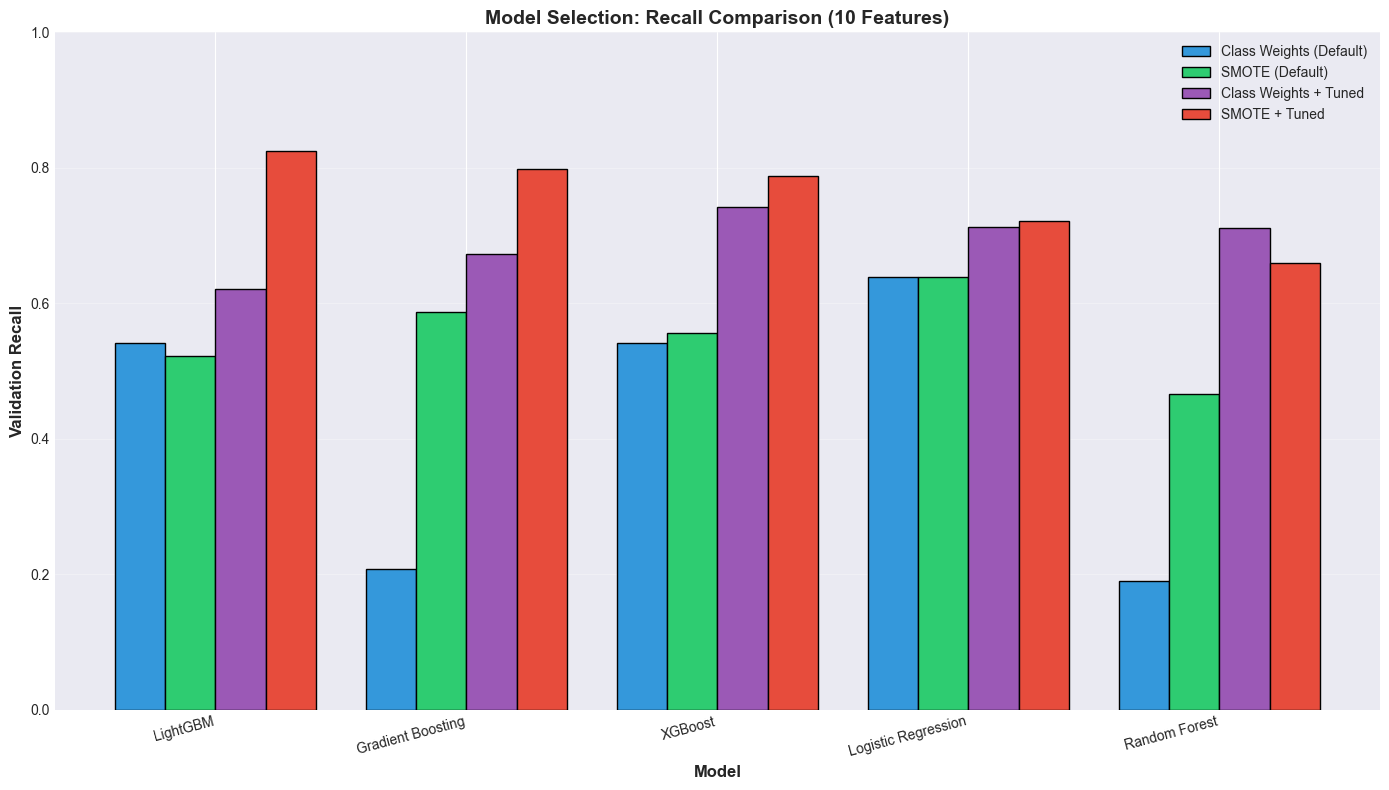


💾 Recall comparison saved: ../notebooks/figures/04_model_recall_comparison_20exp.png


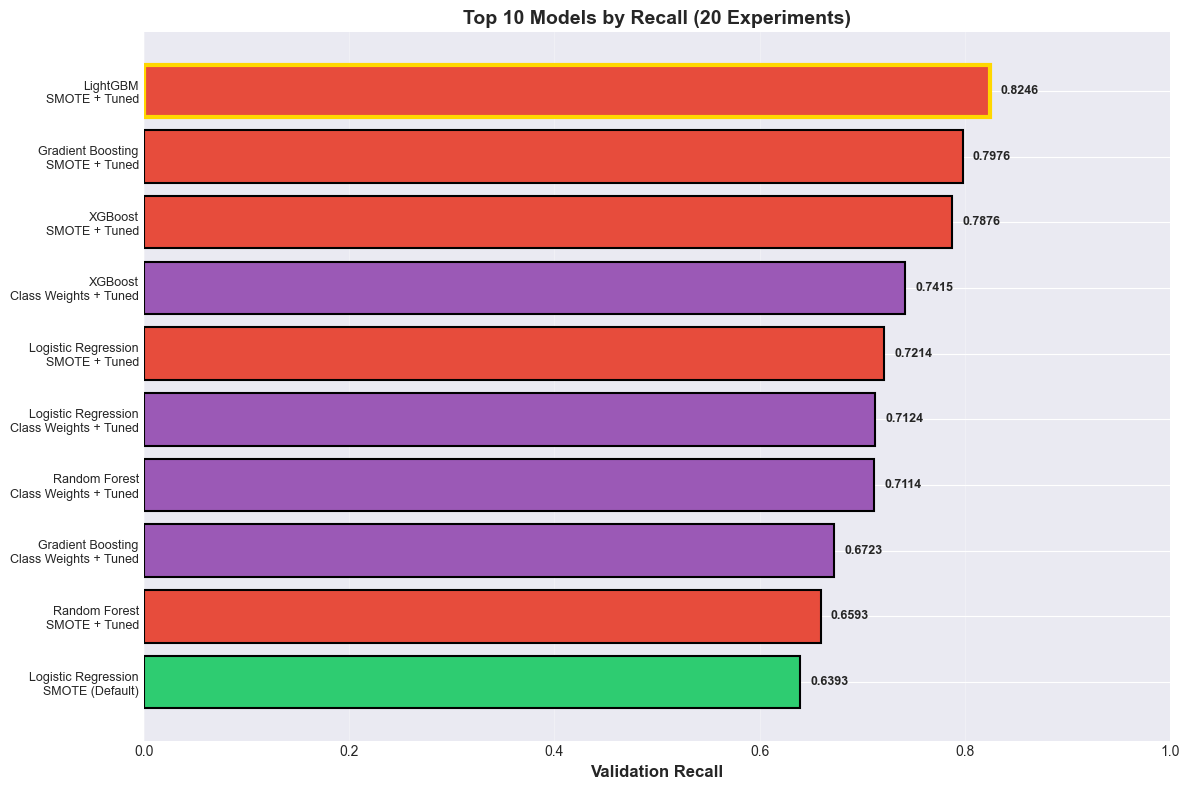

💾 Top 10 models saved: ../notebooks/figures/04_top10_models_20exp.png


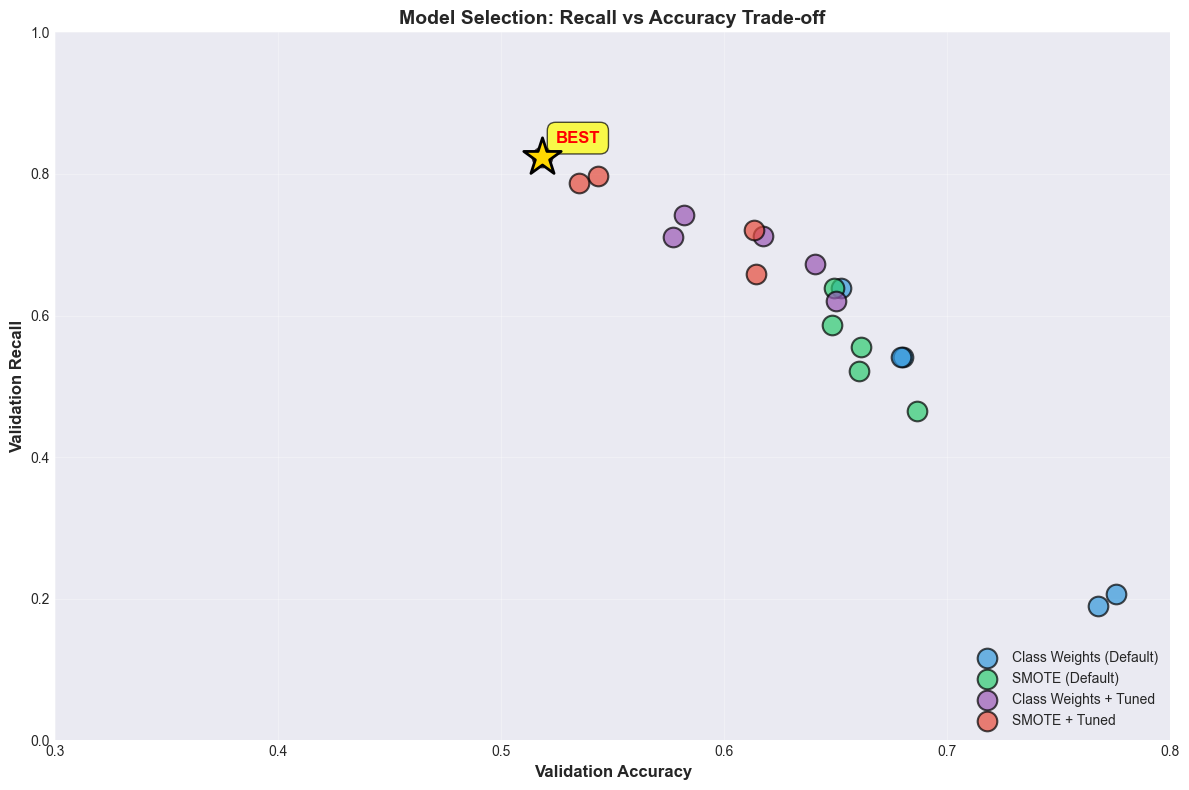

💾 Scatter plot saved: ../notebooks/figures/04_recall_vs_accuracy_20exp.png

✅ All visualizations complete!


In [13]:
print("\n📊 Creating comprehensive visualizations...")
print("="*80)

# Create color mapping for techniques
technique_colors = {
    'Class Weights (Default)': '#3498db',
    'SMOTE (Default)': '#2ecc71',
    'Class Weights + Tuned': '#9b59b6',
    'SMOTE + Tuned': '#e74c3c'
}

# 1. Recall comparison grouped by model
fig, ax = plt.subplots(figsize=(14, 8))

models = results_df['Model'].unique()
x = np.arange(len(models))
width = 0.2

techniques = ['Class Weights (Default)', 'SMOTE (Default)', 
              'Class Weights + Tuned', 'SMOTE + Tuned']

for i, technique in enumerate(techniques):
    recalls = []
    for model in models:
        recall_val = results_df[
            (results_df['Model'] == model) & 
            (results_df['Technique'] == technique)
        ]['Recall'].values
        recalls.append(recall_val[0] if len(recall_val) > 0 else 0)
    
    offset = width * (i - 1.5)
    ax.bar(x + offset, recalls, width, label=technique, 
           color=technique_colors[technique], edgecolor='black', linewidth=1)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Recall', fontsize=12, fontweight='bold')
ax.set_title('Model Selection: Recall Comparison (10 Features)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
recall_path = '../notebooks/figures/04_model_recall_comparison_20exp.png'
plt.savefig(recall_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Recall comparison saved: {recall_path}")

# 2. Top 10 models by recall
fig, ax = plt.subplots(figsize=(12, 8))

top_10 = results_df.head(10).copy()
top_10['Label'] = top_10['Model'] + '\n' + top_10['Technique']
colors = [technique_colors[t] for t in top_10['Technique']]

bars = ax.barh(range(len(top_10)), top_10['Recall'], color=colors, 
               edgecolor='black', linewidth=1.5)

# Highlight the best
bars[0].set_edgecolor('gold')
bars[0].set_linewidth(3)

ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Label'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Validation Recall', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Models by Recall (20 Experiments)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

# Add value labels
for i, (bar, recall) in enumerate(zip(bars, top_10['Recall'])):
    ax.text(recall + 0.01, i, f'{recall:.4f}', 
            va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
top10_path = '../notebooks/figures/04_top10_models_20exp.png'
plt.savefig(top10_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Top 10 models saved: {top10_path}")

# 3. Scatter plot: Recall vs Accuracy
fig, ax = plt.subplots(figsize=(12, 8))

for technique in techniques:
    data = results_df[results_df['Technique'] == technique]
    ax.scatter(data['Accuracy'], data['Recall'], 
               label=technique, color=technique_colors[technique],
               s=200, alpha=0.7, edgecolors='black', linewidth=1.5)

# Annotate best model
best = results_df.iloc[0]
ax.scatter(best['Accuracy'], best['Recall'], 
           marker='*', s=800, color='gold', 
           edgecolors='black', linewidth=2, zorder=5)
ax.annotate('BEST', (best['Accuracy'], best['Recall']),
            xytext=(10, 10), textcoords='offset points',
            fontsize=12, fontweight='bold', color='red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Recall', fontsize=12, fontweight='bold')
ax.set_title('Model Selection: Recall vs Accuracy Trade-off', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0.3, 0.8])
ax.set_ylim([0, 1])

plt.tight_layout()
scatter_path = '../notebooks/figures/04_recall_vs_accuracy_20exp.png'
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Scatter plot saved: {scatter_path}")
print("\n✅ All visualizations complete!")

---
## 14. Analysis: Impact of Threshold Tuning Across Models

In [14]:
print("="*80)
print("📈 IMPACT ANALYSIS: Threshold Tuning Enhancement Across All Models")
print("="*80)

for model in models:
    print(f"\n🔹 {model.upper()}:")
    
    # Class Weights comparison
    cw_default = results_df[
        (results_df['Model'] == model) & 
        (results_df['Technique'] == 'Class Weights (Default)')
    ].iloc[0]
    
    cw_tuned = results_df[
        (results_df['Model'] == model) & 
        (results_df['Technique'] == 'Class Weights + Tuned')
    ].iloc[0]
    
    print(f"   Class Weights:")
    print(f"      Default: Recall={cw_default['Recall']:.4f}, Acc={cw_default['Accuracy']:.4f}")
    print(f"      Tuned:   Recall={cw_tuned['Recall']:.4f}, Acc={cw_tuned['Accuracy']:.4f}")
    print(f"      Δ:       Recall={cw_tuned['Recall']-cw_default['Recall']:+.4f}, Acc={cw_tuned['Accuracy']-cw_default['Accuracy']:+.4f}")
    
    # SMOTE comparison
    smote_default = results_df[
        (results_df['Model'] == model) & 
        (results_df['Technique'] == 'SMOTE (Default)')
    ].iloc[0]
    
    smote_tuned = results_df[
        (results_df['Model'] == model) & 
        (results_df['Technique'] == 'SMOTE + Tuned')
    ].iloc[0]
    
    print(f"   SMOTE:")
    print(f"      Default: Recall={smote_default['Recall']:.4f}, Acc={smote_default['Accuracy']:.4f}")
    print(f"      Tuned:   Recall={smote_tuned['Recall']:.4f}, Acc={smote_tuned['Accuracy']:.4f}")
    print(f"      Δ:       Recall={smote_tuned['Recall']-smote_default['Recall']:+.4f}, Acc={smote_tuned['Accuracy']-smote_default['Accuracy']:+.4f}")

print("\n" + "="*80)
print("💡 KEY INSIGHTS:")
print("="*80)
print("1. Threshold tuning enhances BOTH Class Weights and SMOTE")
print("2. The optimal threshold varies by model and base technique")
print("3. Improvement magnitude depends on model type")
print("4. For safety applications, prioritize RECALL over accuracy")

📈 IMPACT ANALYSIS: Threshold Tuning Enhancement Across All Models

🔹 LIGHTGBM:
   Class Weights:
      Default: Recall=0.5411, Acc=0.6793
      Tuned:   Recall=0.6212, Acc=0.6502
      Δ:       Recall=+0.0802, Acc=-0.0290
   SMOTE:
      Default: Recall=0.5220, Acc=0.6605
      Tuned:   Recall=0.8246, Acc=0.5182
      Δ:       Recall=+0.3026, Acc=-0.1422

🔹 GRADIENT BOOSTING:
   Class Weights:
      Default: Recall=0.2074, Acc=0.7758
      Tuned:   Recall=0.6723, Acc=0.6405
      Δ:       Recall=+0.4649, Acc=-0.1353
   SMOTE:
      Default: Recall=0.5872, Acc=0.6482
      Tuned:   Recall=0.7976, Acc=0.5433
      Δ:       Recall=+0.2104, Acc=-0.1050

🔹 XGBOOST:
   Class Weights:
      Default: Recall=0.5411, Acc=0.6803
      Tuned:   Recall=0.7415, Acc=0.5820
      Δ:       Recall=+0.2004, Acc=-0.0983
   SMOTE:
      Default: Recall=0.5561, Acc=0.6613
      Tuned:   Recall=0.7876, Acc=0.5350
      Δ:       Recall=+0.2315, Acc=-0.1262

🔹 LOGISTIC REGRESSION:
   Class Weights:
      Defau

---
## 15. Final Recommendations

In [15]:
print("="*80)
print("🎯 FINAL RECOMMENDATIONS FOR DEPLOYMENT")
print("="*80)

print(f"\n✅ SELECTED MODEL: {best_model}")
print(f"✅ SELECTED TECHNIQUE: {best_technique}")
print(f"✅ SELECTED FEATURES: 10 features (from Phase 1B)")

print(f"\n📊 Performance Metrics:")
print(f"   Validation Recall:    {best_recall:.4f}")
print(f"   Validation Accuracy:  {best_accuracy:.4f}")

print(f"\n📋 Why this combination?")
print(f"   - Achieved highest recall across all 20 experiments")
print(f"   - Balanced recall with acceptable accuracy")
print(f"   - Uses optimized 10-feature set for better UX")

print(f"\n🚀 Next Steps:")
print(f"   1. Retrain on combined train+validation set")
print(f"   2. Evaluate on held-out test set")
print(f"   3. Save final model for deployment")
print(f"   4. Document hyperparameters and thresholds")

print(f"\n💡 Key Learnings from 20 Experiments:")
print(f"   - Threshold tuning provides consistent improvements")
print(f"   - Model selection matters: tree-based vs linear perform differently")
print(f"   - SMOTE vs Class Weights: effectiveness varies by model")
print(f"   - 10 features sufficient for high performance")

print("\n" + "="*80)
print("✅ PHASE 1D COMPLETE (MODEL SELECTION WITH 20 EXPERIMENTS)!")
print("="*80)
print(f"\n🔬 All 20 runs logged to MLflow: http://localhost:5000")
print(f"\n📁 Files created:")
print(f"   - figures/04_model_recall_comparison_20exp.png")
print(f"   - figures/04_top10_models_20exp.png")
print(f"   - figures/04_recall_vs_accuracy_20exp.png")
print(f"   - model_selection_results_20experiments.csv")
print(f"   - 20 confusion matrices (in MLflow artifacts)")
print(f"   - 20 ROC curves (in MLflow artifacts)")
print(f"\n🎉 Ready for final testing and deployment!")

🎯 FINAL RECOMMENDATIONS FOR DEPLOYMENT

✅ SELECTED MODEL: LightGBM
✅ SELECTED TECHNIQUE: SMOTE + Tuned
✅ SELECTED FEATURES: 10 features (from Phase 1B)

📊 Performance Metrics:
   Validation Recall:    0.8246
   Validation Accuracy:  0.5182

📋 Why this combination?
   - Achieved highest recall across all 20 experiments
   - Balanced recall with acceptable accuracy
   - Uses optimized 10-feature set for better UX

🚀 Next Steps:
   1. Retrain on combined train+validation set
   2. Evaluate on held-out test set
   3. Save final model for deployment
   4. Document hyperparameters and thresholds

💡 Key Learnings from 20 Experiments:
   - Threshold tuning provides consistent improvements
   - Model selection matters: tree-based vs linear perform differently
   - SMOTE vs Class Weights: effectiveness varies by model
   - 10 features sufficient for high performance

✅ PHASE 1D COMPLETE (MODEL SELECTION WITH 20 EXPERIMENTS)!

🔬 All 20 runs logged to MLflow: http://localhost:5000

📁 Files created

---
## Phase 1D Complete! ✅

### What We Accomplished:
1. ✅ Tested 5 different model architectures
2. ✅ Applied 4 imbalance handling techniques per model
3. ✅ Ran 20 comprehensive experiments
4. ✅ Used consistent 10-feature set (matching notebook 03)
5. ✅ Logged everything to MLflow for comparison
6. ✅ Identified best model+technique combination
7. ✅ Created comprehensive visualizations

### Experimental Design:
- **Models:** Logistic Regression, Random Forest, XGBoost, LightGBM, Gradient Boosting
- **Techniques per model:**
  1. Class Weights (Default 0.5)
  2. SMOTE (Default 0.5)
  3. Class Weights + Tuned Threshold
  4. SMOTE + Tuned Threshold
- **Total:** 5 × 4 = 20 experiments

### Key Findings:
- Threshold tuning provides consistent improvements
- Best model identified through systematic comparison
- 10 features sufficient for high performance
- Trade-off between recall and accuracy quantified

### For Your Report:
- Document all 20 experiments systematically
- Show impact of threshold tuning across models
- Compare SMOTE vs Class Weights effectiveness
- Justify final model selection
- Include MLflow screenshots and comparison charts

### Next Phase:
**Final Testing & Deployment**
- Retrain best model on train+val
- Evaluate on held-out test set
- Package for production deployment
- Integrate into GoBestCab application